In [33]:
%matplotlib widget

In [34]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [35]:
spectra_c = []
spectra_dx = []
spectra_sx = []

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_center_{i}_gas_exp.csv")
    spectra_c.append(df)

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_dx_{i}_gas_exp.csv")
    spectra_dx.append(df)

for i in range(1, 5):
    df = pd.read_csv(f"Spectrum_sx_{i}_gas_exp.csv")
    spectra_sx.append(df)

In [36]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def real_flux(spectrum_sx, spectrum_c, spectrum_dx):
    flux_sx = spectrum_sx['Flux']
    flux_c = spectrum_c['Flux']
    flux_dx = spectrum_dx['Flux']
    err_flux_sx = spectrum_sx['Error_flux']
    err_flux_c = spectrum_c['Error_flux']
    err_flux_dx = spectrum_dx['Error_flux']
    num = [1, 2, 3, 8, 12]
    real_err = []
    real_flux = []
    for i in num:
        mean = np.mean([flux_sx[i], flux_dx[i]])
        real_flux.append(flux_c[i] - mean)

        real_err.append(np.sqrt(err_flux_c[i]**2 + (err_flux_sx[i]/2)**2 + (err_flux_dx[i]/2)**2))
    
    print(real_flux, real_err)
        
    return np.array(real_flux), np.array(real_err)

def one_diff_flux(spectrum_l, spectrum_c):
    flux_l = spectrum_l['Flux']
    flux_c = spectrum_c['Flux']
    err_flux_l = spectrum_l['Error_flux']
    err_flux_c = spectrum_c['Error_flux']
    
    num = [1, 2, 3, 8, 12]
    real_err = []
    real_flux = []
    for i in num:
        real_flux.append(flux_c[i] - flux_l[i])

        real_err.append(np.sqrt(err_flux_c[i]**2 + (err_flux_l[i])**2))
    
    print(real_flux, real_err)
        
    return np.array(real_flux), np.array(real_err)
    
def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(flux, err_flux):

    HB   = flux[0]
    HA   = flux[1]
    SII  = flux[2]
    OIII = flux[3]
    NII  = flux[4]
   
    OIII_HB = np.log10(OIII / HB) #if OIII > 0 and HB > 0 #else np.nan
    NII_HA  = np.log10(NII / HA) # if NII >  0 and HA > 0 #else np.nan
    SII_HA  = np.log10(SII / HA) # if SII > 0 and HA > 0 #else np.nan
    print('log ratio OIII_HB: ', OIII_HB)
    print('log ratio NII_HA: ', NII_HA)
    print('log ratio SII_HA: ', SII_HA)

    err_OIII_HB = error_ratio(err_flux[3], err_flux[0], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[4], err_flux[1], NII, HA)
    err_SII_HA  = error_ratio(err_flux[2], err_flux[1], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

In [37]:
spectra_c[3]

,Name,Flux,Error_flux
0,Hgamma,0.240385,0.046245
1,Hbeta,0.866193,0.072621
2,Halpha,3.086154,0.100487
3,[SII]6716,0.437207,0.018389
4,[SII]6731,0.414370,0.032361
5,HeII4687,0.000000,0.015376
6,HeI5876,0.038742,0.009979
7,[OIII]4959,0.177584,0.037157
8,[OIII]5007,0.532753,0.037157
9,[OI]6300,0.092892,0.040517


In [38]:
spectra_dx[3]

,Name,Flux,Error_flux
0,Hgamma,0.069198,0.055996
1,Hbeta,0.374756,0.059029
2,Halpha,1.597049,0.049331
3,[SII]6716,0.120415,0.036878
4,[SII]6731,0.282782,0.037355
5,HeII4687,0.091638,0.029668
6,HeI5876,0.000000,0.019849
7,[OIII]4959,0.082621,0.040011
8,[OIII]5007,0.247864,0.040011
9,[OI]6300,0.035155,0.023900


[5.940125161370618, 29.734971764963912, 1.7434757479995326, 9.367327495334543, 5.603336978583162] [1.150710114135045, 1.5460030850664108, 0.3791877408194608, 1.0846974653826067, 0.43101992594056576]
log ratio OIII_HB:  0.19782010818268997
log ratio NII_HA:  -0.7248207891982436
log ratio SII_HA:  -1.2318516197935454
[2.28069433294944, 12.321130457759512, 1.5076078228922416, 1.5079187847711688, 5.241636881677237] [0.22649992047638876, 0.15970927643341448, 0.12134861565098475, 0.1908832927146415, 0.10336640020668272]
log ratio OIII_HB:  -0.1796891320009114
log ratio NII_HA:  -0.3711836243881138
log ratio SII_HA:  -0.9123621736520291
[0.3481214946097875, 1.2219664921573847, 0.22465730166736306, 0.2283695907351928, 0.41373096754057603] [0.08610835290353518, 0.10551597260391904, 0.03375958593290411, 0.046029009041614416, 0.04641498080182507]
log ratio OIII_HB:  -0.18309256584740682
log ratio NII_HA:  -0.47034126835369916
log ratio SII_HA:  -0.7355387588555878
[3.3521475988620466, 15.15644705

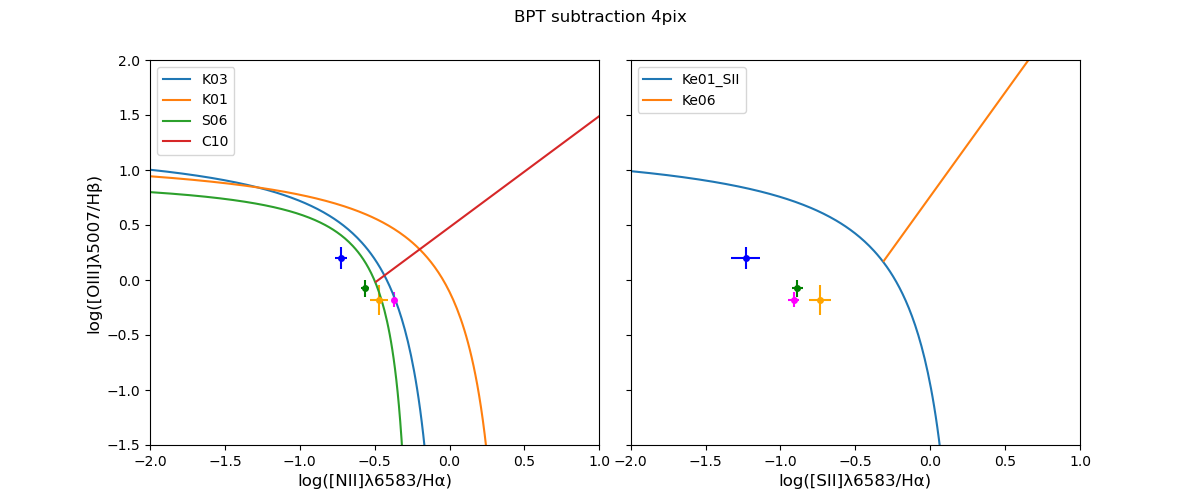

In [44]:
NII_HA = np.zeros(len(spectra_c))
OIII_HB = np.zeros(len(spectra_c))
SII_HA = np.zeros(len(spectra_c))
err_OIII_HB = np.zeros(len(spectra_c))
err_NII_HA = np.zeros(len(spectra_c))
err_SII_HA = np.zeros(len(spectra_c))

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)
fig.suptitle('BPT subtraction 4pix')
colors = ['blue', 'green', 'magenta', 'orange']
num_both = [0, 2, 3]
#num_single = [1, 3]
for i in num_both:
    diff_flux, diff_err = real_flux(spectra_sx[i], spectra_c[i], spectra_dx[i])
    OIII_HB[i], NII_HA[i], SII_HA[i], err_OIII_HB[i], err_NII_HA[i], err_SII_HA[i] = ratio(diff_flux, diff_err)
    #ax[0].errorbar(x = np.log10(NII_HA[i]), y = np.log10(OIII_HB[i]), xerr = err_NII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
    #markersize = 4, marker = 'o')
    #ax[1].errorbar(x = np.log10(SII_HA[i]), y = np.log10(OIII_HB[i]), xerr = err_SII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
    #markersize = 4, marker = 'o')

#diff_flux, diff_err = one_diff_flux(spectra_sx[3], spectra_c[3])
#OIII_HB[3], NII_HA[3], SII_HA[3], err_OIII_HB[3], err_NII_HA[3], err_SII_HA[3] = ratio(diff_flux, diff_err)

diff_flux, diff_err = one_diff_flux(spectra_dx[1], spectra_c[1])
OIII_HB[1], NII_HA[1], SII_HA[1], err_OIII_HB[1], err_NII_HA[1], err_SII_HA[1] = ratio(diff_flux, diff_err)
for i in range(4):
    ax[0].errorbar(x = NII_HA[i], y = OIII_HB[i], xerr = err_NII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
               markersize = 4, marker = 'o')
    ax[1].errorbar(x = SII_HA[i], y = OIII_HB[i], xerr = err_SII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
              markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')

ax[0].plot(x3, C10(x3), label = 'C10')    
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_diff.png', bbox_inches='tight')  

In [40]:
OIII_HB

array([ 0.19782011, -0.07584777, -0.17968913, -0.18309257])

In [41]:
NII_HA

array([-0.72482079, -0.56629954, -0.37118362, -0.47034127])

In [42]:
SII_HA

array([-1.23185162, -0.88702379, -0.91236217, -0.73553876])